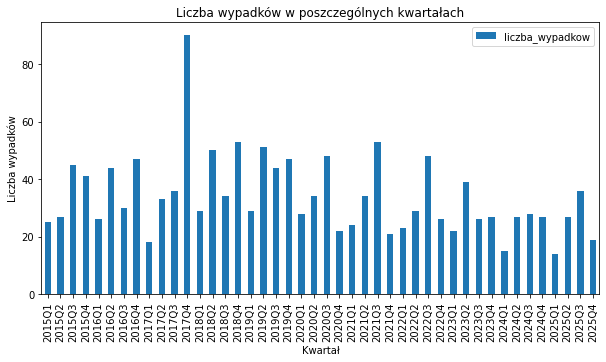

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytanie danych z podaniem PEŁNEJ ścieżki do Twojego folderu Downloads
df = pd.read_csv(r"C:\Users\Sylwia\Downloads\city_7_4_data.csv")

# 2. Tworzenie wykresu kolumnowego
df.plot(x="quarter", y="liczba_wypadkow", kind="bar", figsize=(10, 5))

# 3. Dodanie tytułu i etykiet
plt.title("Liczba wypadków w poszczególnych kwartałach")
plt.xlabel("Kwartał")
plt.ylabel("Liczba wypadków")

# 4. Zapisywanie wykresu do pliku jako obrazek PNG
plt.savefig('wykres.png', dpi=300, bbox_inches='tight')

# 5. Wyświetlenie wykresu w notatniku
plt.show()

In [7]:
# 1. Sprawdzamy sumę wypadków i zabitych dla całego zbioru
suma_wypadkow = df['liczba_wypadkow'].sum()
suma_zabitych = df['liczba_zabitych'].sum()

print(f"Łączna liczba wypadków w bazie: {suma_wypadkow}")
print(f"Łączna liczba ofiar śmiertelnych: {suma_zabitych}")

# 2. GRUPOWANIE: Sprawdzamy średnią liczbę wypadków w zależności od liczby zabitych
# (Pokazuje to, czy przy konkretnej liczbie ofiar liczba wypadków była wyższa)
raport_grupowany = df.groupby('liczba_zabitych')['liczba_wypadkow'].mean().reset_index()

# Wyświetlamy wynik grupowania
print("\nŚrednia liczba wypadków pogrupowana według liczby zabitych:")
print(raport_grupowany)

Łączna liczba wypadków w bazie: 1496
Łączna liczba ofiar śmiertelnych: 41

Średnia liczba wypadków pogrupowana według liczby zabitych:
   liczba_zabitych  liczba_wypadkow
0                0        29.888889
1                1        37.625000
2                2        35.428571
3                3        39.500000
4                5        29.000000


In [12]:
# 1. WYKRYWANIE BRAKÓW: Sprawdzamy, ile pustych pól (braków danych) jest w każdej kolumnie
print("Liczba brakujących wartości w poszczególnych kolumnach:")
print(df.isnull().sum())

# 2. CZYSZCZENIE: Tworzymy bezpieczną kopię naszej bazy danych
df_czyste = df.copy()

# 3. NAPRAWA BRAKÓW: Jeśli w kolumnie 'liczba_wypadkow' byłyby jakieś puste pola, 
# zastąpimy je wartością 0 (lub średnią), aby nie psuły dalszych obliczeń
df_czyste['liczba_wypadkow'] = df_czyste['liczba_wypadkow'].fillna(0)

# Alternatywnie: usunięcie całych wierszy, które mają jakiekolwiek puste pola
# df_czyste = df_czyste.dropna()

print("\nCzyszczenie zakończone sukcesem! Liczba braków po naprawie:")
print(df_czyste.isnull().sum())

Liczba brakujących wartości w poszczególnych kolumnach:
liczba_rannych                      0
liczba_zabitych                     0
liczba_wszystkich_poszkodowanych    0
liczba_wypadkow                     0
quarter                             0
dtype: int64

Czyszczenie zakończone sukcesem! Liczba braków po naprawie:
liczba_rannych                      0
liczba_zabitych                     0
liczba_wszystkich_poszkodowanych    0
liczba_wypadkow                     0
quarter                             0
dtype: int64
